In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats.qmc import LatinHypercube

In [3]:
class RBFModel:
    """
    A class to implement a Function Value based Radial Basis Function model
    (FV-RBF)
    """

    def __init__(self, X, y, C=None):
        """
        Constructor for the RBF model.

        Parameters:
        X : np.ndarray
            Input data with shape (n_samples, n_features).
        y : np.ndarray
            Target data with shape (n_samples, ).
        C : np.ndarray, optional
            Centres for the RBF model, default is X. Shape: (n_centres, n_features).
        """
        self.X = X
        self.y = y
        self.C = X if C is None else C

        self._n_samples, self._n_features = self.X.shape
        self._n_centres = self.C.shape[0]

    def FV_fit(self, epsi=1):
        """
        Fit the Function Value Radial Basis Function (FV-RBF) model.

        Parameters:
        epsi : float, optional
            The shape parameter for the RBF. Default is 1.
        """
        self.epsi = epsi

        from scipy.spatial.distance import cdist

        # Calculate the distance between each pair of points
        dist_matrix = cdist(self.X, self.C, metric="euclidean")

        # Calculate the RBF kernel matrix using the Gaussian basis function
        kernel_matrix = np.exp(-self.epsi * (dist_matrix**2))

        # Solve the linear system to find the coefficients/weigths
        if self._n_centres == self._n_samples:  # interpolation fit
            self.coefficients = np.linalg.solve(kernel_matrix, self.y)

        else:  # regression fit
            self.coefficients = np.linalg.solve(
                kernel_matrix.T @ kernel_matrix, kernel_matrix.T @ self.y
            )

    def __call__(self, Xnew):
        """
        Predict using the RBF model.

        Parameters:
        Xnew : np.ndarray
           New points for prediction. Shape: (n_samples, n_features).

        Returns:
        y_pred : np.ndarray
            Predicted output. Shape: (n_samples, 1).
        """
        # Calculate the distance between each input point and the
        # centres of the model
        from scipy.spatial.distance import cdist

        dist_matrix = cdist(Xnew, self.C, metric="euclidean")

        # Calculate the RBF kernel matrix
        kernel_matrix = np.exp(-self.epsi * (dist_matrix**2))

        # Calculate the predicted output
        y_pred = kernel_matrix @ self.coefficients

        return y_pred

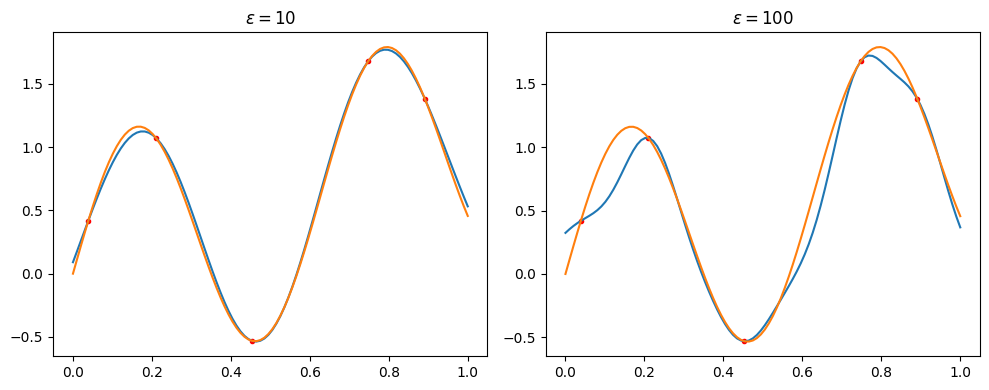

In [8]:
def Example(x):
    return np.sin(10 * x) + x


fig, ax = plt.subplots(1, 2, figsize=(10, 4))

lhs_sampler = LatinHypercube(d=1)

X = lhs_sampler.random(n=5)
y = Example(X)

for i, epsi in enumerate([10, 100]):
    model = RBFModel(X, y)
    model.FV_fit(epsi=epsi)

    X_pred = np.linspace(0, 1, 100).reshape(-1, 1)
    y_pred = model(X_pred)

    X_actual = np.linspace(0, 1, 100).reshape(-1, 1)
    y_actual = Example(X_actual)

    ax[i].set_title(rf"$\epsilon = {epsi}$")
    ax[i].plot(X, y, "r.", label="Samples")
    ax[i].plot(X_pred, y_pred, label="Model")
    ax[i].plot(X_actual, y_actual, label="Target")

fig.tight_layout()
plt.show()